In [1]:
# ================================================
# Adventure Works - Retail EDA Project
# Author: Arpita
# Dataset: AdventureWorks Sales (Microsoft)
# Goal: End-to-End EDA + Power BI Dark Dashboard
# ================================================

In [2]:
# =============================================================
# STEP 0 — Setup Environment
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [10]:
# =============================================================
# STEP 1 — Load Dataset
# =============================================================

file_path = "C:/Users/Lenovo/OneDrive/Desktop/AdventureWorks/AdventureWorks Sales.xlsx"
sales = pd.read_excel(file_path, sheet_name="Sales_data")
customers = pd.read_excel(file_path, sheet_name="Customer_data")
products = pd.read_excel(file_path, sheet_name="Product_data")
territories = pd.read_excel(file_path, sheet_name="Sales Territory_data")
resellers = pd.read_excel(file_path, sheet_name="Reseller_data")
dates = pd.read_excel(file_path, sheet_name="Date_data")
orders = pd.read_excel(file_path,sheet_name="Sales Order_data")

print("All sheets loaded successfully")

All sheets loaded successfully


In [17]:
# =============================================================
# STEP 2 — Basic Exploration
# =============================================================

# 2a — Check size of each table
print("Sales_data:            ", sales.shape)
print("Customer_data:         ", customers.shape)
print("Product_data:          ", products.shape)
print("Sales Territory_data:  ", territories.shape)
print("Reseller_data:         ", resellers.shape)
print("Date_data:             ", dates.shape)
print("Sales Order_data:      ", orders.shape)

Sales_data:             (121253, 15)
Customer_data:          (18485, 7)
Product_data:           (397, 9)
Sales Territory_data:   (11, 4)
Reseller_data:          (702, 8)
Date_data:              (1461, 7)
Sales Order_data:       (121253, 4)


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,Extended Amount,Unit Price Discount Pct,Product Standard Cost,Total Product Cost,Sales Amount
0,43659001,676,-1,349,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
1,43659002,676,-1,350,20170702,20170712,20170709.0,5,3,2024.994,6074.982,0,1898.0944,5694.2832,6074.982
2,43659003,676,-1,351,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
3,43659004,676,-1,344,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
4,43659005,676,-1,345,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994


In [18]:
# 2b — Preview the main Sales table
sales.head() 

,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,Extended Amount,Unit Price Discount Pct,Product Standard Cost,Total Product Cost,Sales Amount
0,43659001,676,-1,349,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
1,43659002,676,-1,350,20170702,20170712,20170709.0,5,3,2024.994,6074.982,0,1898.0944,5694.2832,6074.982
2,43659003,676,-1,351,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
3,43659004,676,-1,344,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
4,43659005,676,-1,345,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994


In [19]:
# 2c — Check missing values
sales.isnull().sum()

SalesOrderLineKey             0
ResellerKey                   0
CustomerKey                   0
ProductKey                    0
OrderDateKey                  0
DueDateKey                    0
ShipDateKey                2113
SalesTerritoryKey             0
Order Quantity                0
Unit Price                    0
Extended Amount               0
Unit Price Discount Pct       0
Product Standard Cost         0
Total Product Cost            0
Sales Amount                  0
dtype: int64

In [20]:
# 2d — Check data types
sales.dtypes

SalesOrderLineKey            int64
ResellerKey                  int64
CustomerKey                  int64
ProductKey                   int64
OrderDateKey                 int64
DueDateKey                   int64
ShipDateKey                float64
SalesTerritoryKey            int64
Order Quantity               int64
Unit Price                 float64
Extended Amount            float64
Unit Price Discount Pct      int64
Product Standard Cost      float64
Total Product Cost         float64
Sales Amount               float64
dtype: object

In [21]:
# 2e — Summary statistics
sales[['Order Quantity', 'Unit Price', 'Sales Amount', 'Total Product Cost', 'Unit Price Discount Pct']].describe()

,Order Quantity,Unit Price,Sales Amount,Total Product Cost,Unit Price Discount Pct
count,121253.000000,121253.000000,121253.000000,121253.000000,121253.0
mean,2.266138,465.180515,905.621091,802.107230,0.0
std,2.491806,752.041893,1693.746343,1660.416044,0.0
min,1.000000,1.328200,1.374000,0.856500,0.0
25%,1.000000,21.490000,24.990000,10.842300,0.0
50%,1.000000,49.990000,134.982000,98.983600,0.0
75%,3.000000,602.346000,1120.490000,999.259500,0.0
max,44.000000,3578.270000,27893.619000,38530.385400,0.0


In [22]:
# =============================================================
# STEP 3 — Data Cleaning
# =============================================================

# 3a — Convert OrderDateKey to real date format
sales['OrderDate'] = pd.to_datetime(sales['OrderDateKey'], format='%Y%m%d')

#Extract useful time columns
sales['Year'] = sales['OrderDate'].dt.year
sales['Month'] = sales['OrderDate'].dt.month
sales['MonthName'] = sales['OrderDate'].dt.strftime('%b')
sales['Quarter'] = sales['OrderDate'].dt.quarter

print("Date columns created")
print(sales[['OrderDateKey', 'OrderDate', 'Year', 'Month', 'MonthName', 'Quarter']].head())

Date columns created
   OrderDateKey  OrderDate  Year  Month MonthName  Quarter
0      20170702 2017-07-02  2017      7       Jul        3
1      20170702 2017-07-02  2017      7       Jul        3
2      20170702 2017-07-02  2017      7       Jul        3
3      20170702 2017-07-02  2017      7       Jul        3
4      20170702 2017-07-02  2017      7       Jul        3


In [23]:
# 3b — Handle missing ShipDate
sales['ShipDateKey'] = sales['ShipDateKey'].fillna(0).astype(int)

print("Missing ShipDate handled")

Missing ShipDate handled


In [24]:
# 3c — Calculate actual Discount Amount
sales['Discount Amount'] = sales['Extended Amount'] - sales['Sales Amount']

print("Discount Amount column created")
print(f"\nSample discounts:\n{sales['Discount Amount'].describe()}")

Discount Amount column created

Sample discounts:
count    121253.000000
mean          4.350473
std          62.309687
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4005.237600
Name: Discount Amount, dtype: float64


In [25]:
# 3d — Create Profit column
sales['Profit'] = sales['Sales Amount'] - sales['Total Product Cost']
sales['Profit Margin %'] = (sales['Profit']/sales['Sales Amount']*100).round(2)

print("Profit columns created")
print(f"\n Average Profit per order: ${sales['Profit'].mean():.2f}")
print(f"Average Profit Margin: {sales['Profit Margin %'].mean():.2f}")

Profit columns created

 Average Profit per order: $103.51
Average Profit Margin: 30.30


In [27]:
# 3e — Merge all tables into one master dataframe
master = sales.copy()

# Merge with territories
master = master.merge(territories, on='SalesTerritoryKey', how='left')

# Merge with products
master = master.merge(products, on='ProductKey', how='left')

# Merge with customers
master = master.merge(customers, on='CustomerKey', how='left')

# Merge with orders (to get the channel info)
master = master.merge(orders, on='SalesOrderLineKey', how='left')

print("Master Dataframe created!")
print(f"Shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")

Master Dataframe created!
Shape: (121253, 43)

Columns: ['SalesOrderLineKey', 'ResellerKey', 'CustomerKey', 'ProductKey', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'SalesTerritoryKey', 'Order Quantity', 'Unit Price', 'Extended Amount', 'Unit Price Discount Pct', 'Product Standard Cost', 'Total Product Cost', 'Sales Amount', 'OrderDate', 'Year', 'Month', 'MonthName', 'Quarter', 'Discount Amount', 'Profit', 'Profit Margin %', 'Region', 'Country', 'Group', 'SKU', 'Product', 'Standard Cost', 'Color', 'List Price', 'Model', 'Subcategory', 'Category', 'Customer ID', 'Customer', 'City', 'State-Province', 'Country-Region', 'Postal Code', 'Channel', 'Sales Order', 'Sales Order Line']


In [28]:
# 3f — Sanity check on master dataframe

print("=== MASTER DATAFRAME SUMMARY ===\n")
print(f"Total Orders:  {master.shape[0]:,}")
print(f"Total Columns: {master.shape[1]}")
print(f"Date Range:  {master['OrderDate'].min()} to {master['OrderDate'].max()}")
print(f"Total Revenue:  ${master['Sales Amount'].sum():,.2f}")
print(f"Total Profit: ${master['Profit'].sum():,.2f}")
print(f"Countries: {master['Country'].nunique()} - {list(master['Country'].unique())}")
print(f"Product Categories:  {master['Category'].nunique()} - {list(master['Category'].unique())}")
print(f"Sales Channels:  {list(master['Channel'].unique())}")

=== MASTER DATAFRAME SUMMARY ===

Total Orders:  121,253
Total Columns: 43
Date Range:  2017-07-01 00:00:00 to 2020-06-15 00:00:00
Total Revenue:  $109,809,274.20
Total Profit: $12,551,366.25
Countries: 6 - ['United States', 'Canada', 'United Kingdom', 'France', 'Australia', 'Germany']
Product Categories:  4 - ['Bikes', 'Clothing', 'Accessories', 'Components']
Sales Channels:  ['Reseller', 'Internet']


In [29]:
# =============================================================
# STEP 4 — Create Key Metrics
# =============================================================

# 4a — Label channel type clearly
master['CustomerType'] = master['Channel'].apply(lambda x: 'B2B' if x=='Reseller' else 'B2C')

#Check the split
print(master['CustomerType'].value_counts())
print()
print(master['CustomerType'].value_counts(normalize=True).mul(100).round(2))

CustomerType
B2B    60855
B2C    60398
Name: count, dtype: int64

CustomerType
B2B    50.19
B2C    49.81
Name: proportion, dtype: float64


In [30]:
# 4b — Revenue per order & Price Bands
master['Revenue per Order'] = (master['Sales Amount']/master['Order Quantity']).round(2)

master['Price Band'] = pd.cut(master['Unit Price'], bins=[0, 50, 200, 500, 4000], labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])

print("Key Metrics created")
print("\nPrice Band Distribution:")
print(master['Price Band'].value_counts())

Key Metrics created

Price Band Distribution:
Price Band
Budget       60827
Luxury       33238
Premium      14888
Mid-Range    12300
Name: count, dtype: int64


In [31]:
# =============================================================
# STEP 5 — Revenue by Category
# =============================================================

category_revenue = master.groupby('Category')['Sales Amount'].sum().sort_values(ascending=False).reset_index()
category_revenue.columns = ['Category', 'Total Revenue']
category_revenue['Revenue(M)'] = (category_revenue['Total Revenue']/1_000_000).round(2)

print(category_revenue)

      Category  Total Revenue  Revenue(M)
0        Bikes   9.462053e+07       94.62
1   Components   1.179908e+07       11.80
2     Clothing   2.117613e+06        2.12
3  Accessories   1.272058e+06        1.27


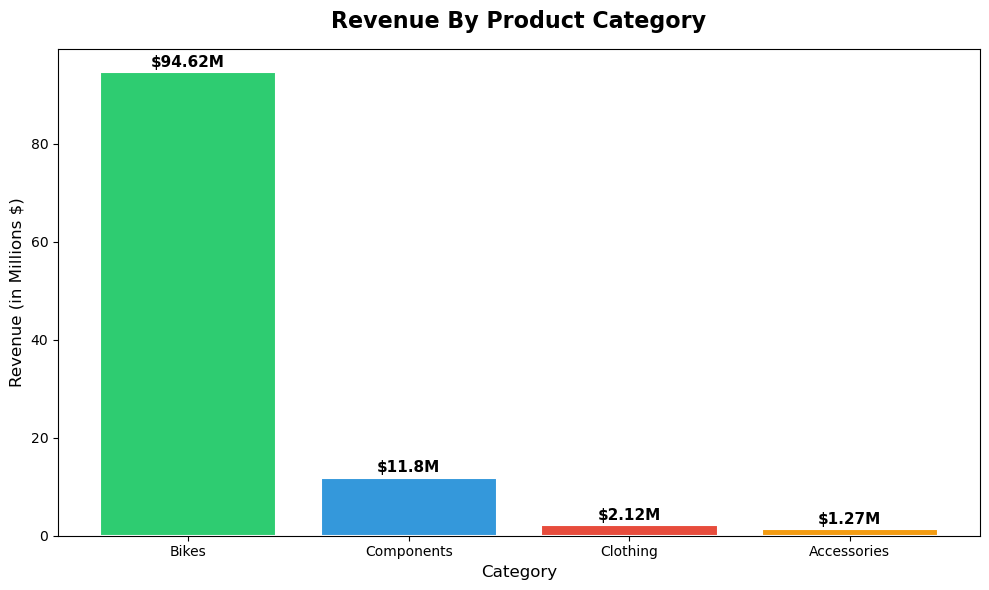

Chart saved


In [33]:
# STEP 5 — Revenue by Category Chart

plt.figure(figsize=(10,6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = plt.bar(category_revenue['Category'], category_revenue['Revenue(M)'], color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, category_revenue['Revenue(M)']):
         plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
         f'${val}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Revenue By Product Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue (in Millions $)', fontsize=12)
plt.tight_layout()
plt.savefig('step5_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")           

In [34]:
# =============================================================
# STEP 6 — Top 10 Products by Revenue
# =============================================================

top_products = master.groupby('Product')['Sales Amount'].sum()\
                     .sort_values(ascending=False)\
                     .head(10)\
                     .reset_index()
top_products.columns = ['Product', 'Total Revenue']
top_products['Revenue (M)'] = (top_products['Total Revenue']/1_000_000).round(2)

print(top_products)

                   Product  Total Revenue  Revenue (M)
0   Mountain-200 Black, 38   4.400593e+06         4.40
1   Mountain-200 Black, 42   4.009495e+06         4.01
2  Mountain-200 Silver, 38   3.693678e+06         3.69
3  Mountain-200 Silver, 42   3.438479e+06         3.44
4  Mountain-200 Silver, 46   3.434257e+06         3.43
5   Mountain-200 Black, 46   3.309673e+06         3.31
6       Road-250 Black, 44   2.516857e+06         2.52
7       Road-250 Black, 48   2.347656e+06         2.35
8       Road-250 Black, 52   2.012448e+06         2.01
9         Road-150 Red, 56   1.847819e+06         1.85


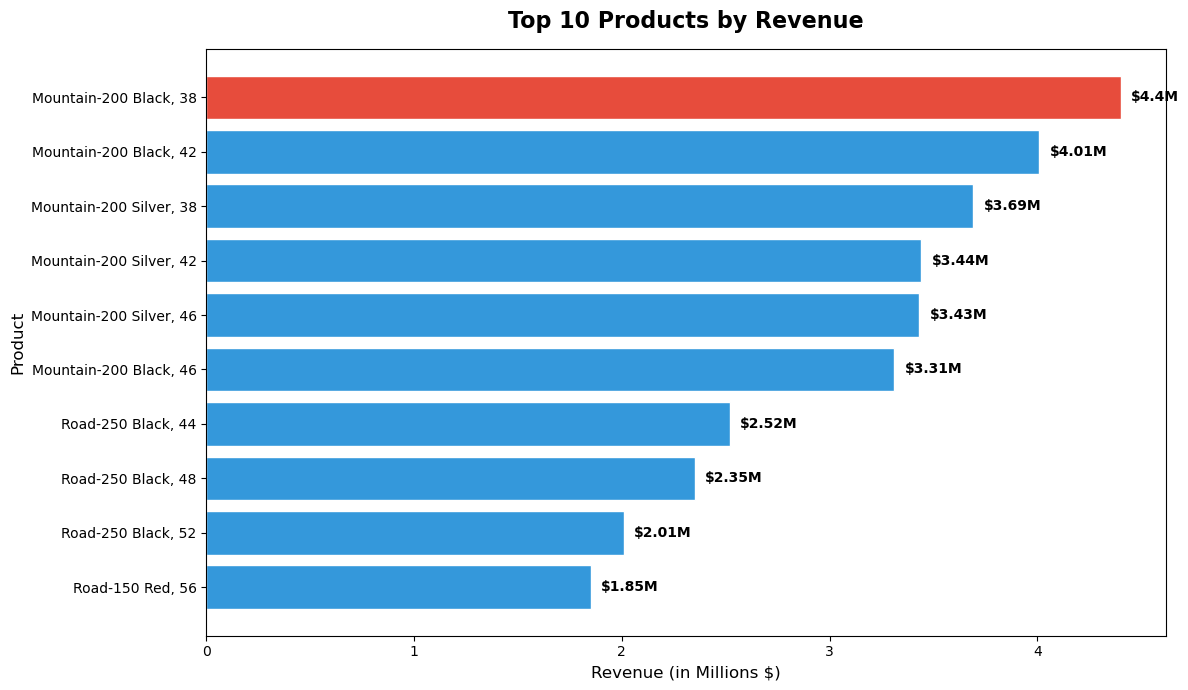

Chart saved


In [35]:
# STEP 6 — Top Products Chart

plt.figure(figsize=(12,7))

colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(top_products))]

bars = plt.barh(top_products['Product'][::-1],
                top_products['Revenue (M)'][::-1],
                color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_products['Revenue (M)'][::-1]):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'${val}M', va='center', fontweight='bold', fontsize=10)

plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Revenue (in Millions $)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('step6_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")